In [12]:
import string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [13]:
# Change this to your local folder
ROOT = Path(".")

SUMM = pd.read_csv(ROOT / "tauz_N1000_summary.csv")
UNG = pd.read_csv(ROOT / "tauz_N1000_ungated_summary.csv")

TAUS = np.array([0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0], dtype=float)
M0S = np.array([0.9, 0.7, 0.5], dtype=float)
ALPHAS = np.array([0.1, 0.2, 0.3, 0.4, 0.5], dtype=float)

In [21]:
mpl.rcdefaults()
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "mathtext.fontset": "cm",   # LaTeX-like only for math text
    "axes.unicode_minus": False,
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 240,
})

COLOR_BLUE = "#3191AF"   # z_i(0) ~ N(0,1)
COLOR_RED  = "#ED7F54"   # z_i(0) = 1

colors = {"random": COLOR_BLUE, "all_open": COLOR_RED}
labels = {
    "random": r"$z_i(0)\sim\mathcal{N}(0,1)$",
    "all_open": r"$z_i(0)=1$",
}
markers = {"random": "o", "all_open": "s"}
legend_order = ["random", "all_open"]

In [28]:
RAW = pd.read_csv(ROOT / "tauz_N1000_raw.csv")

# gated summaries: mean and std across disorder realizations
SUMM = (
    RAW.groupby(["alpha", "m0_target", "z_init", "tau_z"], as_index=False)
       .agg(
           m_mean=("m_final", "mean"),
           m_std=("m_final", lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
           count=("m_final", "size"),
       )
)

# ungated baseline: deduplicate across z_init and tau_z within each rep
UNG_unique = RAW[["rep", "alpha", "m0_target", "m_ungated"]].drop_duplicates()

UNG = (
    UNG_unique.groupby(["alpha", "m0_target"], as_index=False)
              .agg(
                  m_mean=("m_ungated", "mean"),
                  m_std=("m_ungated", lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
                  count=("m_ungated", "size"),
              )
)

SUMM.to_csv(ROOT / "tauz_N1000_summary_std_local.csv", index=False)
UNG.to_csv(ROOT / "tauz_N1000_ungated_summary_std_local.csv", index=False)

In [29]:
def draw_common(ax, alpha, m0, summ, ung):
    u = ung[
        (np.isclose(ung.alpha, alpha)) &
        (np.isclose(ung.m0_target, m0))
    ].iloc[0]

    # ungated mean ± std
    ax.axhspan(u.m_mean - u.m_std, u.m_mean + u.m_std, color="0.88", zorder=0)
    ax.axhline(u.m_mean, color="0.45", ls=(0, (3, 2)), lw=1.1, zorder=1)

    # gated mean ± std
    for z_init in legend_order:
        d = summ[
            (np.isclose(summ.alpha, alpha)) &
            (np.isclose(summ.m0_target, m0)) &
            (summ.z_init == z_init)
        ].sort_values("tau_z")

        x = d.tau_z.to_numpy()
        y = d.m_mean.to_numpy()
        s = d.m_std.to_numpy()

        ax.fill_between(x, y - s, y + s, color=colors[z_init], alpha=0.16, lw=0)
        ax.plot(
            x, y,
            marker=markers[z_init],
            ms=3.7,
            mec=colors[z_init],
            mew=0.0,
            color=colors[z_init],
            lw=1.6,
            label=labels[z_init] if (alpha == ALPHAS[0] and m0 == M0S[0]) else None,
            zorder=3,
        )

    ax.set_xscale("log")
    ax.set_xlim(0.1, 330)
    ax.set_xticks([0.1, 1, 10, 100])   # no 300 label
    ax.get_xaxis().set_major_formatter(mticker.FormatStrFormatter("%g"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    ax.set_ylim(0.10, 1.03)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

In [46]:
def make_version_rowlabels_std(summ, ung):
    fig, axs = plt.subplots(
        len(M0S), len(ALPHAS),
        figsize=(12.0, 6.55),
        sharex=True, sharey=True,
        constrained_layout=False
    )

    plt.subplots_adjust(
        left=0.115, right=0.995,
        bottom=0.20, top=0.89,
        wspace=0.10, hspace=0.16
    )

    # Column headers
    for j, alpha in enumerate(ALPHAS):
        bbox = axs[0, j].get_position()
        fig.text(
            (bbox.x0 + bbox.x1) / 2,
            0.905,
            rf"$\alpha={alpha:.1f}$",
            ha="center", va="bottom", fontsize=12
        )

    # Row labels and panels
    for i, m0 in enumerate(M0S):
        bbox = axs[i, 0].get_position()
        fig.text(
            bbox.x0 - 0.065,
            (bbox.y0 + bbox.y1) / 2,
            rf"$m(0)={m0:.1f}$",
            rotation=90,
            ha="center", va="center", fontsize=12
        )

        for j, alpha in enumerate(ALPHAS):
            ax = axs[i, j]
            draw_common(ax, alpha, m0, summ, ung)

            if j == 0:
                ax.set_ylabel(r"overlap $m_\mathrm{ss}$")

            if i == len(M0S) - 1:
                ax.set_xlabel(r"modulatory timescale $\tau_z$")

    #fig.supylabel(r"$m_{\mathrm{ss}}$", x=0.040, fontsize=12)

    handles, legend_labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, legend_labels,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.055),
        ncol=2,
        handlelength=2.0,
        columnspacing=1.8,
        handletextpad=0.6,
    )

    return fig

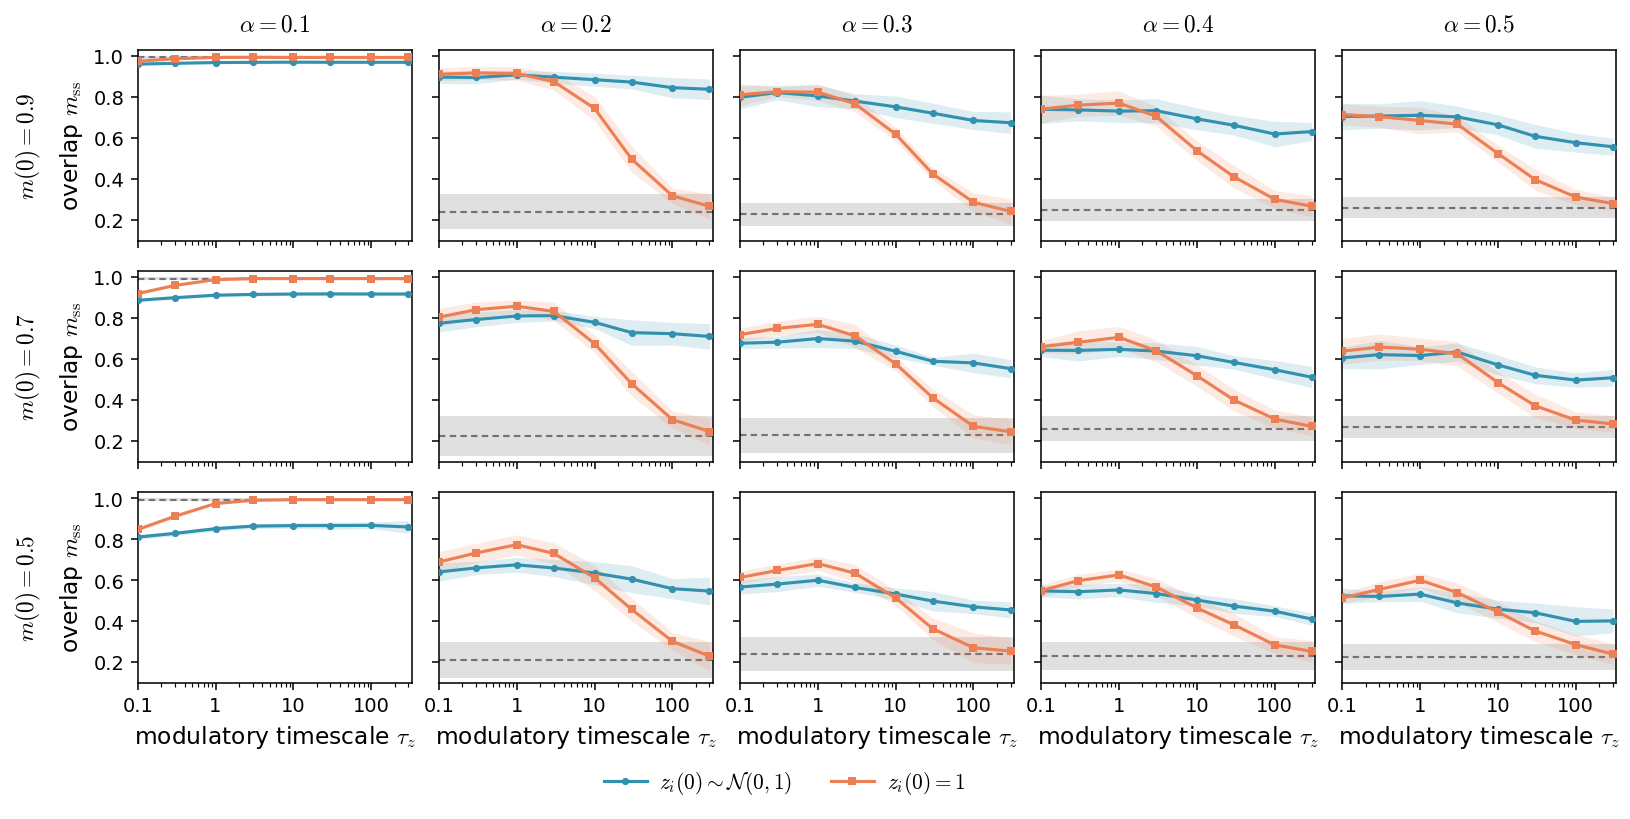

In [47]:
fig = make_version_rowlabels_std(SUMM, UNG)
plt.show()

In [48]:
fig.savefig("figure_mss_vs_tauz_N1000.pdf", bbox_inches="tight")
#fig.savefig("figure_mss_vs_tauz_N1000.png", bbox_inches="tight", dpi=240)